# Single-nucleus RNA-seq beetle (*Nicrophorus vespilloides*): data pre-processing and cell clustering

Burying beetles *Nicrophorus vespilloides* are remarkable for their commitment to **parental care**, where both male and female parents are deeply involved in the nurturing of their offspring.

To investigate how parental care shapes devlopmental gene expression at the single-cell level, we prepared and sequenced two single-nucleus RNA-seq libraries from the **head of first instar larvae of the burying beetle *Nicrophorus vespilloides***. Library 1 hereafter referred to as "**Care**", "**fc**" or "**fc_larvae**" was prepared from larvae that **received parental care**, library 2 "**NoCare**", "**nc**" or "**nc_larvae**" was prepared from larvae were **parental care was removed**.

This notebook presents how the snRNA-seq data was pre-processed and nuclei clustered.

# Table of Contents

1. [Read mapping with CellRanger](#part2)
2. [Nuclei filtering with QClus](#part3)
3. [Additional filtering in Seurat](#part4)
4. [Final clustering](#part5)

## 1. Read mapping with CellRanger <a name="part2"></a>

**[**CellRanger**](https://www.10xgenomics.com/support/software/cell-ranger/latest) (v9.0.1):**

```
cellranger mkref --genome=Nves_ref --fasta=Ni2.purged.folded.filtered_scaffolds_final.sm.renamed.fa --genes=Nvi2.liftoff.mitohifi.final.ok.genename.cellranger.gtf
```

```
cellranger count --id=NC_nves --fastqs=fastqs/NC/ --sample=NC --transcriptome=Nves_ref/ --localcores=24 --create-bam=true --include-introns=true
```

## 2. Nuclei filtering with QClus <a name="part3"></a>

[**CellRanger**](https://www.10xgenomics.com/support/software/cell-ranger/latest)'s cell calling algorithm uses only UMI count and feature counts as metrics to identify high-quality droplets. Additional metrics can be informative to filter out low-quality cells (% mitochondria) or nuclei (% unspliced). 

To filter out low-quality nuclei (contaminated or empty droplets), we used [**QClus**](https://github.com/linnalab/qclus), a python package specifically tailored to the quality control of single-**nuclei** RNA-seq. Contrary to single-cell RNA-seq where the fraction of mitochondrial reads is often a sufficient QC metric, other metrics such as the fraction of unspliced reads are also informative to QC snRNA-seq. [**QClus**](https://github.com/linnalab/qclus) uses the fraction of unspliced reads, the % of counts coming from mitochondria, the total number of counts.

To get the fraction of reads from unspliced transcripts per barcode using [**QClus**](https://github.com/linnalab/qclus):

To run [**QClus**](https://github.com/linnalab/qclus) (custom wrapper script `qclus/filter_nuclei_qclus.py`):

```
python filter_nuclei_qclus.py --unspliced 'QClusOut_NC_nves/fraction_unspliced.csv' --cellranger_dir '/home/rahia/NC_nves/outs/' --use_matrix 'raw' --outdir 'QClusOut_NC_nves/' --min_genes 200
```

```
python filter_nuclei_qclus.py --unspliced 'QClusOut_FC_nves/fraction_unspliced.csv' --cellranger_dir '/home/rahia/FC_nves/outs/' --use_matrix 'raw' --outdir 'QClusOut_FC_nves/' --min_genes 215
```

Even if the [**QClus**](https://github.com/linnalab/qclus) filtering is usually stringent, low-quality nuclei can still remain. For the beetle dataset, after initial dimensionality reduction and clustering, we further filtered out nuclei from a cluster which was driven by low-quality nuclei (see below).

## 3. Additional filtering in Seurat <a name="part4"></a>

### Loading filtered datasets in Seurat

In [2]:
library(Seurat)
library(tidyverse)
library(dittoSeq)

In [3]:
packageVersion("Seurat")

[1] ‘5.4.0’

In [4]:
load_and_filter <- function(cellrangerDir, QClusResults, projectName) { 
    data <- Read10X(data.dir = cellrangerDir)
    obj <- CreateSeuratObject(counts = data, project = projectName,
                              min.cells = 3,
                              min.features = 200)
    
    qclus <- read.table(QClusResults, sep='\t', header = TRUE, row.names=1)
    rownames(qclus) <- paste(rownames(qclus), '-1', sep='')

    obj <- AddMetaData(object = obj, metadata = qclus)
    obj <- subset(obj, subset = qclus== 'passed')
    return(obj)
}

In [6]:
## load and filter each of the 2 libraries
fc.obj <- load_and_filter("expression_data/single-nucleus/cellranger/FC_nves/raw_feature_bc_matrix/",
                          "qclus/FC_nves_qclus_barcodes_res.tsv",
                          "fc_larvae")

nc.obj <- load_and_filter("expression_data/single-nucleus/cellranger/NC_nves/raw_feature_bc_matrix/",
                          "qclus/NC_nves_qclus_barcodes_res.tsv",
                          "nc_larvae")

## combine libraries into a single object
combined.obj <- merge(fc.obj, y=nc.obj, add.cell.ids = c("fc", "nc"))

In [7]:
## subset to only protein coding genes
geneIDs <- data.table::fread("../../genome_assembly/genome_files/genes/gene_models_allinfos_for_snRNAseq.tsv",
                             sep="\t", header=T)

my_genes_to_keep <- geneIDs %>% 
  filter(gene_biotype == "protein-coding") %>% 
  filter(!str_detect(uniprot_match, "^RP[SL]")) %>%
  pull(OLD_gene_name)
combined.obj <- subset(combined.obj, features = my_genes_to_keep)

In [8]:
combined.obj

An object of class Seurat 
11803 features across 23648 samples within 1 assay 
Active assay: RNA (11803 features, 0 variable features)
 2 layers present: counts.fc_larvae, counts.nc_larvae

### Dimensionality reduction, clustering and visualisation - without integration

In [9]:
combined.obj <- SCTransform(combined.obj, vst.flavor = "v2") #Normalisation
combined.obj <- RunPCA(combined.obj, npcs = 200) #PCA

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 10400 by 11871

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = 

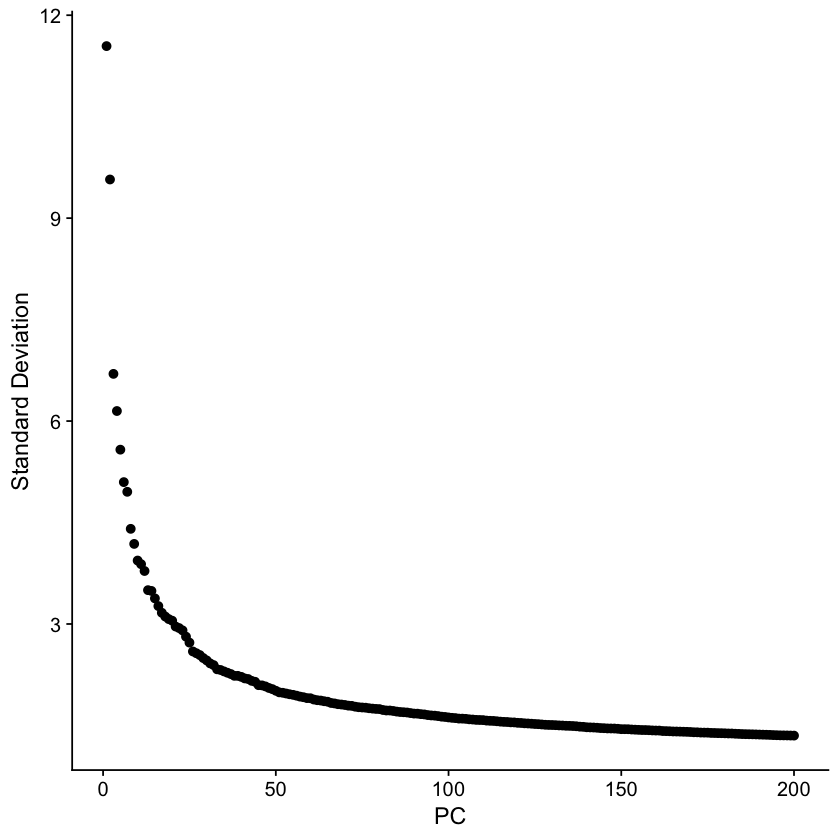

In [10]:
ElbowPlot(combined.obj, ndims = 200)

In [11]:
combined.obj <- FindNeighbors(combined.obj, dims = 1:100, reduction = "pca") #nearest-neighbor graph
combined.obj <- FindClusters(combined.obj, resolution = 0.4) #clustering
combined.obj <- RunUMAP(combined.obj, reduction = "pca", dims = 1:100, reduction.name = "umap") #umap

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 23648
Number of edges: 1016930

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9382
Number of communities: 24
Elapsed time: 2 seconds


2 singletons identified. 22 final clusters.

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
11:56:42 UMAP embedding parameters a = 0.9922 b = 1.112

11:56:42 Read 23648 rows and found 100 numeric columns

11:56:42 Using Annoy for neighbor search, n_neighbors = 30

11:56:42 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:56:45 Writing NN index file to temp file /var/folders/_d/0vfd9dy91jdg4nx769j4yjqm0000gn/T//RtmpVEeUr4/file1846d7b4a8640

11:56:45 Searching Annoy index using 1 thread, search_k = 3000

11:56:49 Annoy recall = 100%



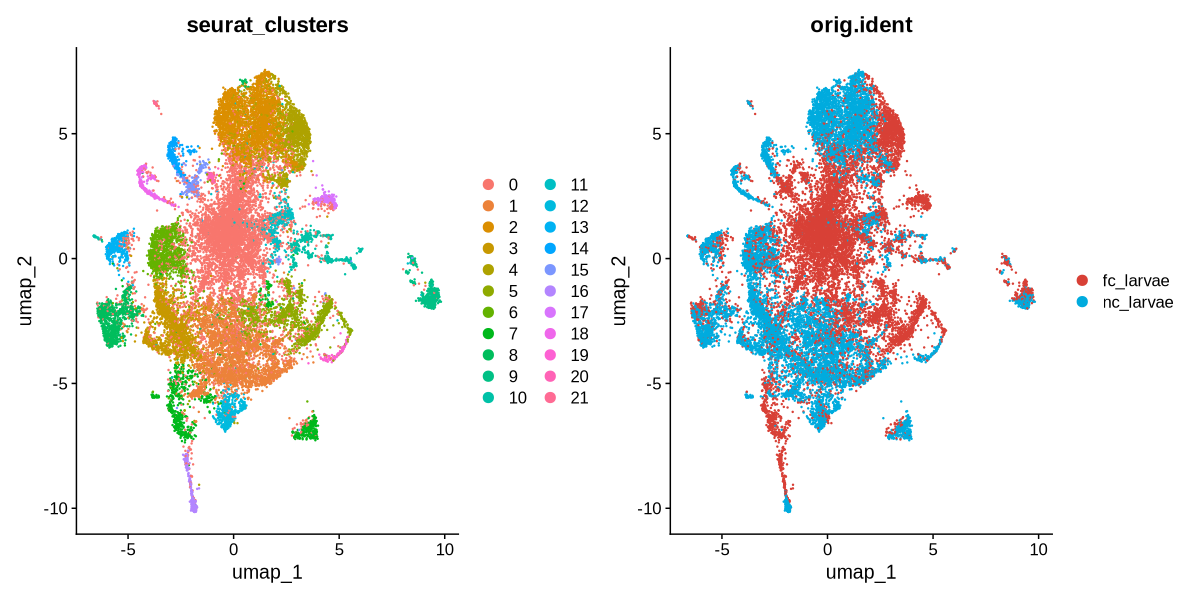

In [11]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

DimPlot(
  combined.obj,
  reduction = "umap",
  group.by = c("seurat_clusters"),
  shuffle = TRUE,
) + DimPlot(
  combined.obj,
  reduction = "umap",
  group.by = c("orig.ident"),
  shuffle = TRUE, cols=c("#d84036ff", "#00abdeff")
)

### Dimensionality reduction, clustering and visualisation - with integration

In [13]:
#integration using CCA (same species, cell-type should match, over-correction is not a concern)
#for Harmony replace with HarmonyIntegration
combined.obj <- IntegrateLayers(combined.obj, CCAIntegration, orig.reduction = "pca",
                                normalization.method="SCT", verbose = TRUE)

#clustering and Umap
combined.obj <- FindNeighbors(combined.obj, dims = 1:100, reduction = "integrated.dr")
combined.obj <- FindClusters(combined.obj, resolution = 0.4)
combined.obj <- RunUMAP(combined.obj, reduction = "integrated.dr", 
                        dims = 1:100, reduction.name = "umap.integrated")

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 12585 anchors

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 23648
Number of edges: 1120281

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9082
Number of communities: 20
Elapsed time: 3 seconds


2 singletons identified. 18 final clusters.

11:58:28 UMAP embedding parameters a = 0.9922 b = 1.112

11:58:28 Read 23648 rows and found 100 numeric columns

11:58:28 Using Annoy for neighbor search, n_neighbors = 30

11:58:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:58:30 Writing NN index file to temp file /var/folders/_d/0vfd9dy91jdg4nx769j4yjqm0000gn/T//RtmpVEeUr4/file1846d73c0a5b0

11:58:30 Searching Annoy index using 1 thread, search_k = 3000

11:58:35 Annoy recall = 100%

11:58:35 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:58:36 Initializing from normalized Laplacian + noise (using RSpectra)

11:58:36 Commencing optimization for 200 epochs, with 1130700 positive edges

11:58:36 Using rng type: pcg

11:58:

In [14]:
combined.obj

An object of class Seurat 
22788 features across 23648 samples within 2 assays 
Active assay: SCT (10985 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, integrated.dr, umap.integrated

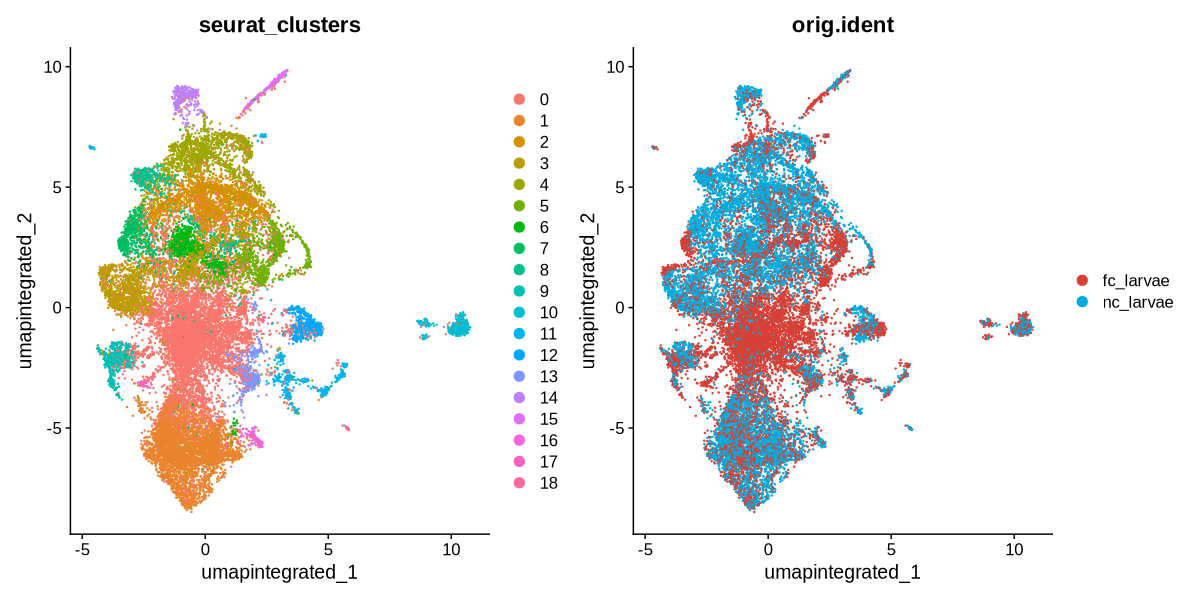

In [14]:
DimPlot(
  combined.obj,
  reduction = "umap.integrated",
  group.by = c("seurat_clusters"),
  shuffle = TRUE,
) + DimPlot(
  combined.obj,
  reduction = "umap.integrated",
  group.by = c("orig.ident"),
  shuffle = TRUE, cols=c("#d84036ff", "#00abdeff")
)

### Additional QC and nuclei filtering

In [17]:
qclus_nc <- read.table('qclus/NC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
qclus_nc <- subset(qclus_nc, qclus=='passed')
rownames(qclus_nc) <- paste('nc_', rownames(qclus_nc), '-1', sep='')

qclus_fc <- read.table('qclus/FC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
rownames(qclus_fc) <- paste('fc_', rownames(qclus_fc), '-1', sep='')
qclus_fc <- subset(qclus_fc, qclus=='passed')
qclus <- bind_rows(qclus_fc, qclus_nc)
qclus <- qclus[rownames(combined.obj@meta.data),]

In [18]:
combined.obj <- AddMetaData(object = combined.obj, metadata = c(qclus["fraction_unspliced"], qclus["pct_counts_MT"]))

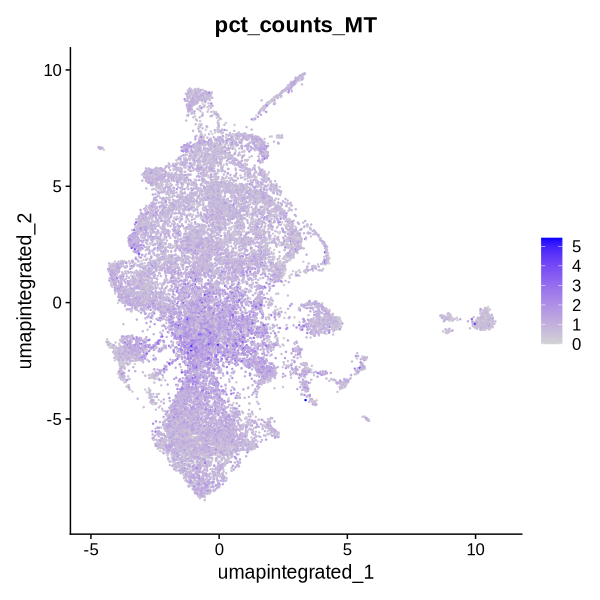

In [17]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 100)

FeaturePlot(combined.obj, features = "pct_counts_MT", reduction = "umap.integrated")

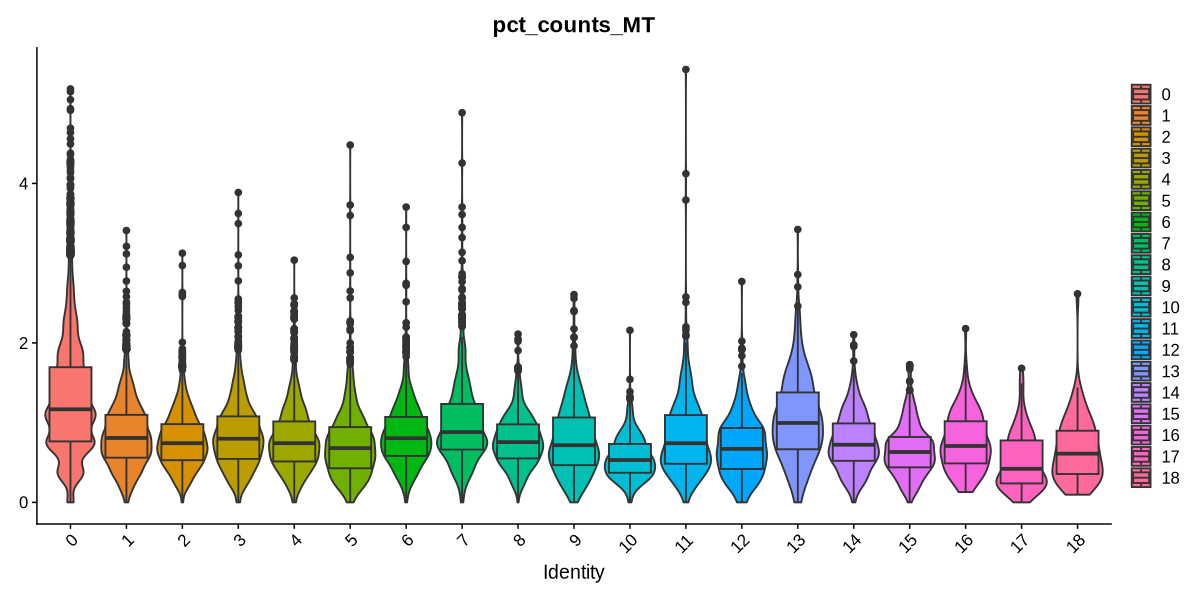

In [18]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

VlnPlot(
  object = combined.obj,
  features = "pct_counts_MT",
  group.by = "seurat_clusters",
  pt.size = 0
) + geom_boxplot()

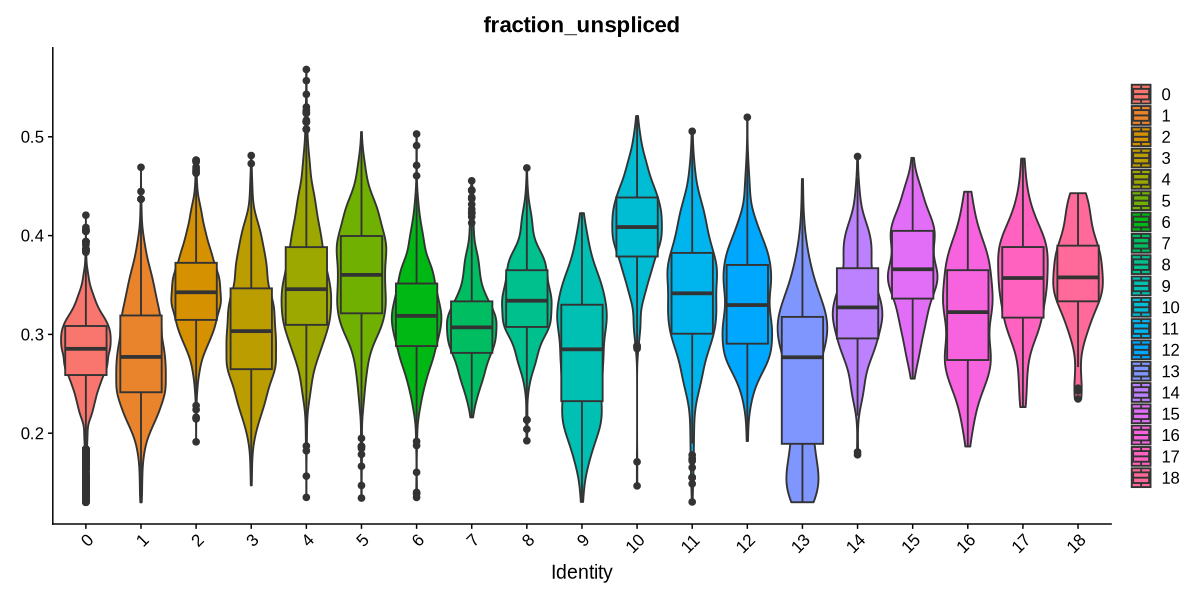

In [19]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

VlnPlot(
  object = combined.obj,
  features = "fraction_unspliced",
  group.by = "seurat_clusters",
  pt.size = 0
) + geom_boxplot()

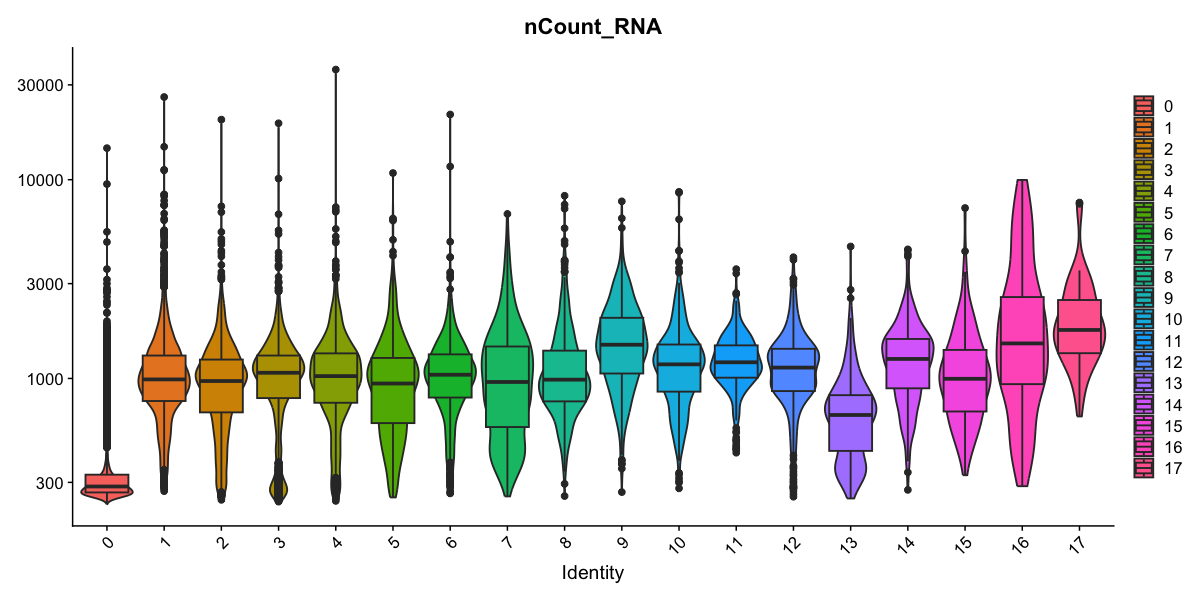

In [534]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

VlnPlot(
  object = obj,
  features = "nCount_RNA",
  group.by = "seurat_clusters",
  pt.size = 0, log=T
) + geom_boxplot()

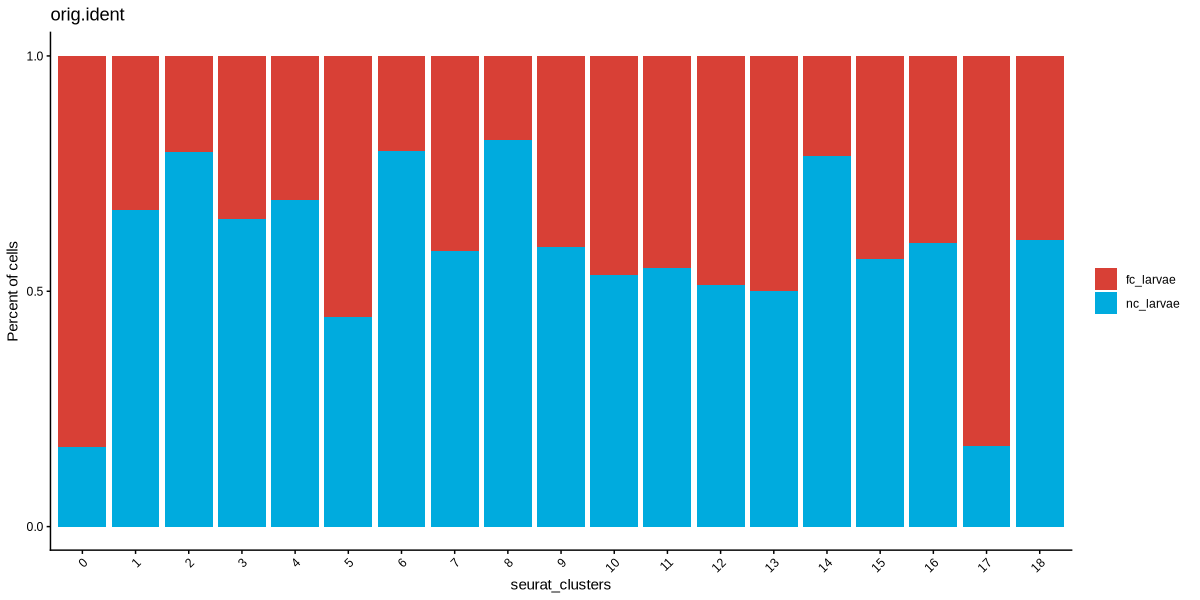

In [19]:
dittoBarPlot(combined.obj, var='orig.ident', group.by = "seurat_clusters", scale='percent', 
             color.panel= c("#d84036ff", "#00abdeff"), retain.factor.levels=TRUE, data.out=F)

We further filtered-out nuclei from cluster 0 (see next section below), as they show properties of low-quality nuclei:
- high % counts from mitochrondria (median = 1.16, higher than all other clusters)
- relatively low unspliced fraction (median = 28%, top 4 lowest)
- low UMI counts (median = 300 , lowest)
- over 85% come from a single library, suggesting batch-effect might prevent correct integration

In [25]:
#SaveSeuratRds(combined.obj, file = "tmp_objects/seurat_combinedobj_qclus.rds")

## 4. Final clustering <a name="part5"></a>

#### Clustering

In [22]:
library(Seurat) #5.0.0
library(tidyverse)
library(dittoSeq)

In [26]:
obj <- LoadSeuratRds("tmp_objects/seurat_combinedobj_qclus.rds")

In [5]:
#filter out cluster 0
obj <- subset(obj, subset = !(seurat_clusters %in% c('0', 0)))

#remove everything except raw counts from the seurat object
DefaultAssay(obj) <- "RNA"
obj@assays$SCT <- NULL
DietSeurat(obj, dimreducs=NULL)

An object of class Seurat 
11803 features across 16201 samples within 1 assay 
Active assay: RNA (11803 features, 0 variable features)
 1 layer present: counts

In [6]:
#Normalize counts for each lib. again

obj.list = SplitObject(obj, split.by = "orig.ident")

fc <- obj.list[['fc_larvae']]
nc <- obj.list[['nc_larvae']]

fc <- SCTransform(fc, vst.flavor = "v2", verbose = FALSE) 
nc <- SCTransform(nc, vst.flavor = "v2", verbose = FALSE)

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [7]:
#Re-do integration (this is the longer version (but equivalent to) "IntegrateLayers" used above
obj.list <- list(nc=nc, fc=fc)
features <- SelectIntegrationFeatures(object.list = obj.list, nfeatures = 3000)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)

anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT", 
                                  anchor.features = features, verbose = TRUE)

obj <- IntegrateData(anchorset = anchors, normalization.method = "SCT", 
                                      verbose = FALSE)

obj <- RunPCA(obj, npcs = 100, reduction.name = "pca.integrated")
obj <- FindNeighbors(obj, dims = 1:100, reduction = "pca.integrated")
obj <- FindClusters(obj, resolution = 0.4)
obj <- RunUMAP(obj, reduction = "pca.integrated", dims = 1:100, reduction.name = "umap.integrated")

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9204 anchors

Filtering anchors

	Retained 7553 anchors



[1] 1


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


[1] 2


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Assay integrated changing from Assay to SCTAssay”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Different cells and/or features from existing assay SCT”
PC_ 1 
Positive:  UN13A, GBRB, ACHA7-2, NVE13765, TITIN-1, CAC1A-2, KCNAS, NVE06674, CUBN-4, SLO-1 
	   NVE00529, SCNA, NVE05512, ADA12-2, CAPS, KCNAB, TMTC1, CDCP2, ERC2-1, EGFLA 
	   MSIR6-2, NVE10489, QVR, GP179, NVE03817, NVE09547, HMCN1-2, 5HTR-2, LCLT1, UNC22 
Negative:  HAM-1, NVE10475, NVE03525, NVE13650, NVE13539, NVE12263, NVE12499, NVE12030, OPCM-2, NVE10306 
	   HR3, NVE13603, NVE10833, NVE06127, ATS1, NVE13012, NVE02393, NVE13015, HR38, NVE09135 
	   LINT, NVE00302, LARP6, NVE09047, NVE08631, ELF1, UN93L-2, FKB14, FAT

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 16201
Number of edges: 828927

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9342
Number of communities: 23
Elapsed time: 1 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:21:25 UMAP embedding parameters a = 0.9922 b = 1.112

10:21:25 Read 16201 rows and found 100 numeric columns

10:21:25 Using Annoy for neighbor search, n_neighbors = 30

10:21:25 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:21:26 Writing NN index file to temp file /var/folders/_d/0vfd9dy91jdg4nx769j4yjqm0000gn/T//RtmpeNFsLO/file83f3f36fe58

10:21:26 Searching Annoy index using 1 thread, search_k = 3000

10:21:29 Annoy recall = 100%

10:21:29 Commencing smooth kNN distance calibra

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


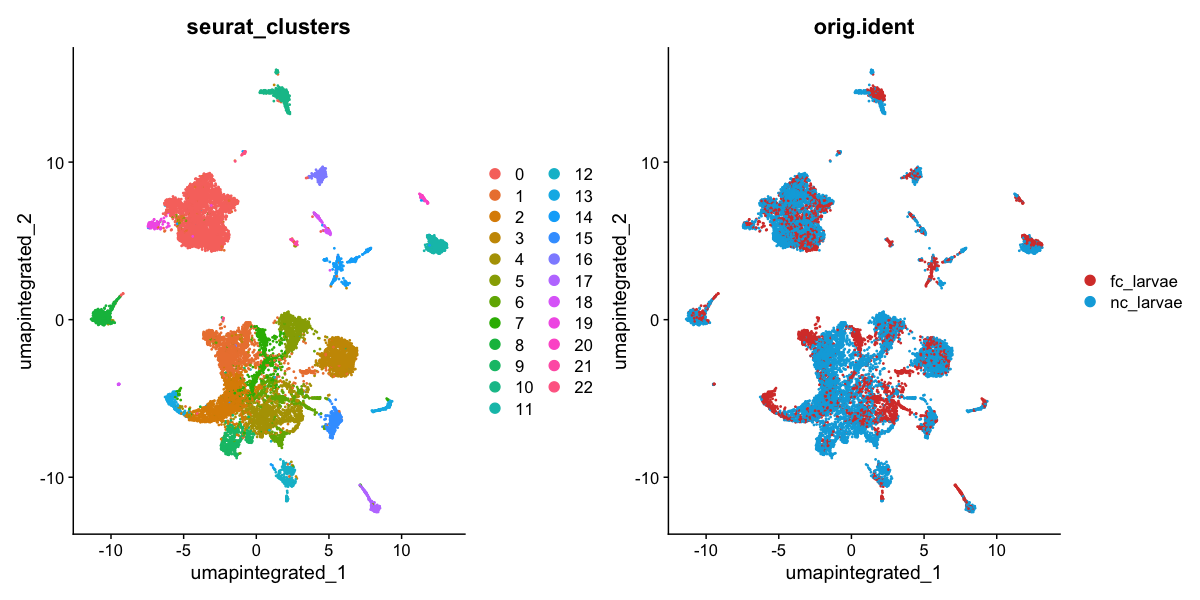

In [8]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

DimPlot(
  obj,
  reduction = "umap.integrated",
  group.by = c("seurat_clusters"),
  shuffle = TRUE,
) + DimPlot(
  obj,
  reduction = "umap.integrated",
  group.by = c("orig.ident"),
  shuffle = TRUE, cols=c("#d84036ff", "#00abdeff")
)

In [11]:
qclus_nc <- read.table('qlcus/NC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
qclus_nc <- subset(qclus_nc, qclus=='passed')
rownames(qclus_nc) <- paste('nc_', rownames(qclus_nc), '-1', sep='')

qclus_fc <- read.table('qclus/FC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
rownames(qclus_fc) <- paste('fc_', rownames(qclus_fc), '-1', sep='')
qclus_fc <- subset(qclus_fc, qclus=='passed')
qclus <- bind_rows(qclus_fc, qclus_nc)

qclus <- qclus[rownames(obj@meta.data),]

obj <- AddMetaData(object = obj, metadata = c(qclus["fraction_unspliced"], qclus["pct_counts_MT"]))

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


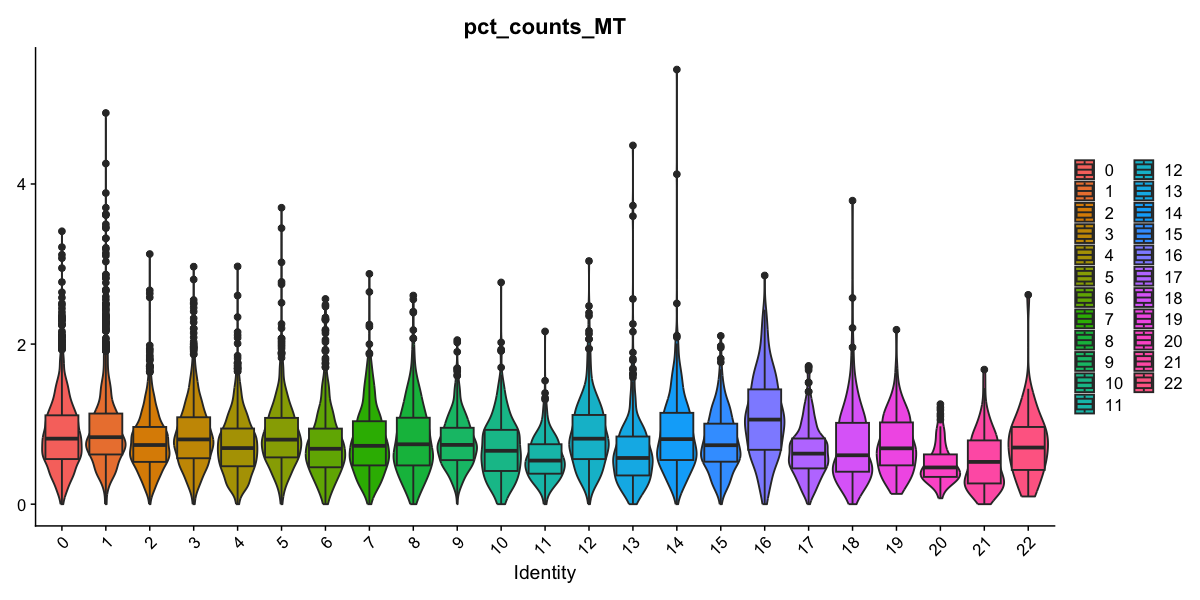

In [12]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

VlnPlot(
  object = obj,
  features = "pct_counts_MT",
  group.by = "seurat_clusters",
  pt.size = 0
) + geom_boxplot()

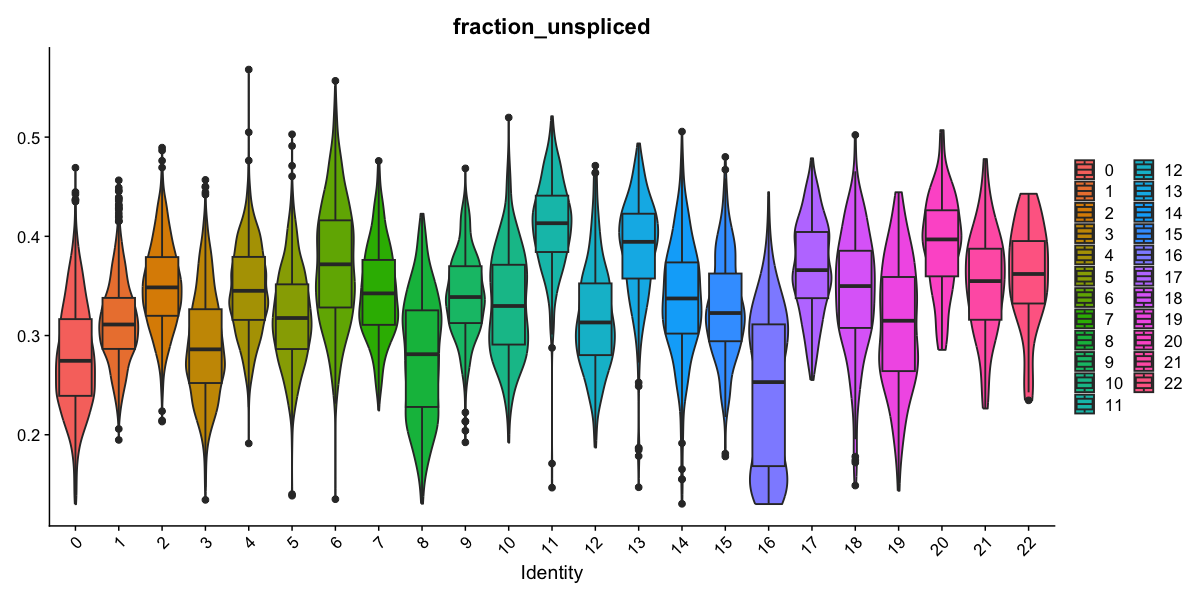

In [13]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)

VlnPlot(
  object = obj,
  features = "fraction_unspliced",
  group.by = "seurat_clusters",
  pt.size = 0
) + geom_boxplot()

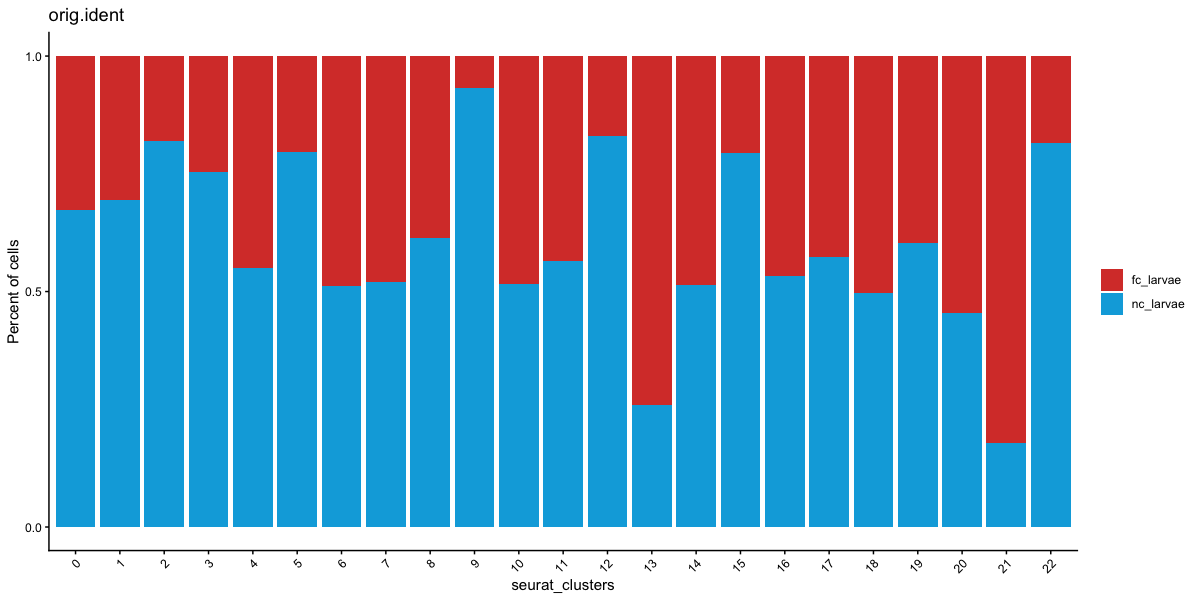

In [14]:
dittoBarPlot(obj, var='orig.ident', group.by = "seurat_clusters", scale='percent', 
             color.panel= c("#d84036ff", "#00abdeff"), retain.factor.levels=TRUE, data.out =F)

In [ ]:
# This is the object with the final clustering saved
# Will load it in the cell annotation notebook where we assign informative name for each cell cluster 
#SaveSeuratRds(obj, file = "tmp_objects/seurat_combinedobj_qclus_integrated.rds")